# From neuron to neural net

Last time, we looked at a single neuron. We discussed the parallels between that neuron with two weights and linear regression. As we add more features (columns in our X matrix), we can add more neurons.

## Activation Functions

However, as we add neurons, each neuron still mostly functions like linear regression. The next thing we can add to our neuron is an **activation function**. Activation functions adjust the output of a neuron by adding some function before the final output. Below are the "linear" activation function that we have modeled so far, plus the more common **ReLU (Rectified Linear Unit)** and **Sigmoid** activation functions.

![Diagrams of the linear, ReLU and Sigmoid activation functions](images/Activation_function_diagrams.png)


Again, the activation function is applied to the output of a neuron and is a hyperparameter of the model. In practice, while layers may use different activation functions, the same function is applied to **all neurons** of each layer. Below is a single neuron with a couple of possible activation functions.

![Diagram of a neuron with activation function](images/Activation_function.png)

## Layers

As we get multiple neurons, we need some way of coordinating their output so we can add a layer to gather the output from multiple neurons into the needed number of outputs (more on that later). However, the other thing that layers do is allow deeper networks with multiple layers, each selected for functional or empirical reasons. This is where deep learning gets its name--as networks grow to have more and more layers of neurons, we refer to them as deep networks--there is no agreed-upon cutoff here...more than three???

![A two layer neural network](images/Neural_network.png)

In [1]:
import random
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [2]:
df = pd.read_csv('data/diabetes.csv')
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# Separate features and target, then create a train/validation split
X = df.drop(columns="Outcome").to_numpy(dtype=np.float32)
y = df["Outcome"].to_numpy(dtype=np.float32)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=seed, stratify=y
)

X_train.shape, X_val.shape

((576, 8), (192, 8))

In [4]:
# Fit the scaler on the training set only to avoid data leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)

In [5]:
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

len(train_loader), len(val_loader)

(18, 6)

In [6]:
class DiabetesNet(nn.Module):
    def __init__(self, input_features):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_features, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
        )

    def forward(self, x):
        return self.network(x)

model = DiabetesNet(input_features=X_train_tensor.shape[1]).to(device)
model

DiabetesNet(
  (network): Sequential(
    (0): Linear(in_features=8, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [7]:
lr = 1e-3
epochs = 100

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

def accuracy_from_logits(logits, targets):
    predictions = (torch.sigmoid(logits) >= 0.5).float()
    return (predictions == targets).float().mean().item()

def train_one_epoch():
    model.train()
    total_loss = 0.0
    total_accuracy = 0.0

    for features, targets in train_loader:
        features = features.to(device)
        targets = targets.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(features)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()

        batch_size = features.size(0)
        total_loss += loss.item() * batch_size
        total_accuracy += accuracy_from_logits(logits, targets) * batch_size

    dataset_size = len(train_loader.dataset)
    return total_loss / dataset_size, total_accuracy / dataset_size

def evaluate():
    model.eval()
    total_loss = 0.0
    total_accuracy = 0.0

    with torch.no_grad():
        for features, targets in val_loader:
            features = features.to(device)
            targets = targets.to(device)

            logits = model(features)
            loss = criterion(logits, targets)

            batch_size = features.size(0)
            total_loss += loss.item() * batch_size
            total_accuracy += accuracy_from_logits(logits, targets) * batch_size

    dataset_size = len(val_loader.dataset)
    return total_loss / dataset_size, total_accuracy / dataset_size

In [8]:
history = {
    "loss": [],
    "val_loss": [],
    "accuracy": [],
    "val_accuracy": [],
}

for epoch in range(epochs):
    train_loss, train_accuracy = train_one_epoch()
    val_loss, val_accuracy = evaluate()

    history["loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["accuracy"].append(train_accuracy)
    history["val_accuracy"].append(val_accuracy)

    if epoch == 0 or (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch + 1:>3}/{epochs} | "
            f"train loss: {train_loss:.4f} | train acc: {train_accuracy:.3f} | "
            f"val loss: {val_loss:.4f} | val acc: {val_accuracy:.3f}"
        )

Epoch   1/100 | train loss: 0.6853 | train acc: 0.628 | val loss: 0.6793 | val acc: 0.651
Epoch  10/100 | train loss: 0.5722 | train acc: 0.736 | val loss: 0.5709 | val acc: 0.698
Epoch  20/100 | train loss: 0.4882 | train acc: 0.778 | val loss: 0.4960 | val acc: 0.719
Epoch  30/100 | train loss: 0.4604 | train acc: 0.788 | val loss: 0.4760 | val acc: 0.734
Epoch  40/100 | train loss: 0.4492 | train acc: 0.797 | val loss: 0.4716 | val acc: 0.740
Epoch  50/100 | train loss: 0.4442 | train acc: 0.797 | val loss: 0.4722 | val acc: 0.734
Epoch  60/100 | train loss: 0.4408 | train acc: 0.788 | val loss: 0.4731 | val acc: 0.734
Epoch  70/100 | train loss: 0.4382 | train acc: 0.790 | val loss: 0.4743 | val acc: 0.734
Epoch  80/100 | train loss: 0.4360 | train acc: 0.792 | val loss: 0.4752 | val acc: 0.729
Epoch  90/100 | train loss: 0.4341 | train acc: 0.793 | val loss: 0.4755 | val acc: 0.734
Epoch 100/100 | train loss: 0.4322 | train acc: 0.799 | val loss: 0.4759 | val acc: 0.740


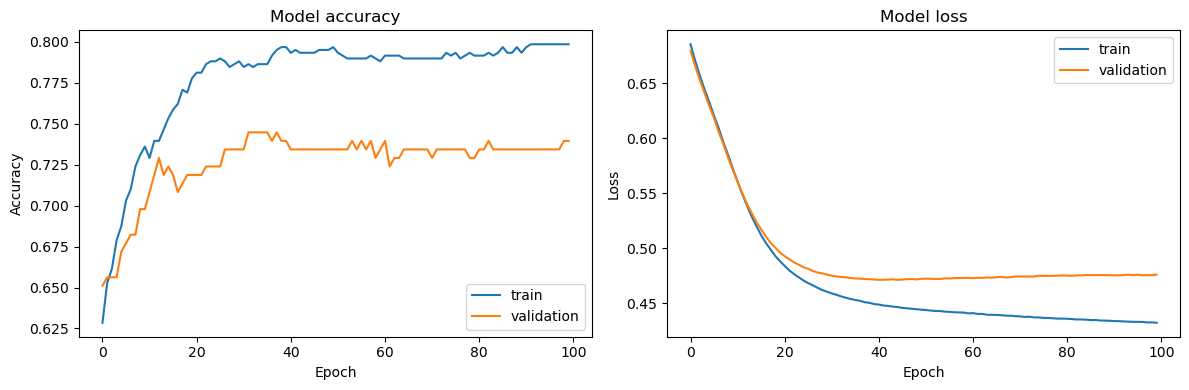

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history["accuracy"], label="train")
axes[0].plot(history["val_accuracy"], label="validation")
axes[0].set_title("Model accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["loss"], label="train")
axes[1].plot(history["val_loss"], label="validation")
axes[1].set_title("Model loss")
axes[1].set_ylabel("Loss")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

# Experimentation

Using what you know so far, try to make the best possible model to predict diabetes with these data.

Things to try:

* Try normalizing the training data to the 0 to 1 range
    ```python
    scaler = MinMaxScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    ```
* Adding layers
* Adjusting the number of neurons per layer
* Different activation functions
* Adjusting the number of epochs
* Adjusting learning rate or batch size

This notebook uses `BCEWithLogitsLoss`, so the model should end with a single raw output neuron. Apply `torch.sigmoid(...)` only when you need probabilities.